# 01 — Exploratory Data Analysis

**Explainable AI for Healthcare Diagnosis using Machine Learning**
Jamia Millia Islamia — Department of Computer Engineering (MDS-391)

Four real clinical datasets, downloaded by `scripts/download_data.py`. This
notebook establishes what we are actually working with before any modelling:
shape, class balance, missingness, feature correlation and distribution shape.

The point of doing this first is that every preprocessing decision in notebook
02 has to be justified by something observed here. In a project about
explainability, an unexplained imputation choice would be a poor start.

In [1]:
import sys
import pathlib

ROOT = pathlib.Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from xai import data, schema

FIGURES = ROOT / "results" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 40)
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({"figure.dpi": 110, "savefig.bbox": "tight"})

print("project root:", ROOT)
print("datasets:", list(schema.DATASETS))

project root: /Users/ajiit/Desktop/xai-healthcare
datasets: ['heart_disease', 'heart_failure', 'diabetes', 'kidney_disease', 'breast_cancer', 'breast_cancer_recurrence', 'breast_cancer_survival', 'cervical_cancer', 'lung_cancer_surgery']


## 1.1 Provenance

Row counts below are asserted against the published figures for each source.
If a number here disagrees with the literature, the download is wrong and
nothing downstream can be trusted.

In [2]:
manifest = pd.read_json(ROOT / "data" / "raw" / "manifest.json")
display(manifest[["slug", "title", "rows", "columns", "positive_rate", "source"]])

for slug, ds in schema.DATASETS.items():
    got = int(manifest.loc[manifest.slug == slug, "rows"].iloc[0])
    assert got == ds.rows, f"{slug}: {got} rows, expected {ds.rows}"
print(f"\nAll {len(schema.DATASETS)} row counts match the published dataset sizes.")

,slug,title,rows,columns,positive_rate,source
0,heart_disease,Heart Disease (Cleveland),303,14,0.4587,https://archive.ics.uci.edu/dataset/45/heart+d...
1,heart_failure,Heart Failure Clinical Records,299,13,0.3211,https://archive.ics.uci.edu/dataset/519
2,diabetes,Pima Indians Diabetes,768,9,0.3490,https://www.kaggle.com/datasets/uciml/pima-ind...
3,kidney_disease,Chronic Kidney Disease,400,25,0.6250,https://archive.ics.uci.edu/dataset/336
4,breast_cancer,Breast Cancer Wisconsin (Diagnostic),569,31,0.3726,https://archive.ics.uci.edu/dataset/17
5,breast_cancer_recurrence,Breast Cancer Recurrence (Ljubljana),286,10,0.2972,https://archive.ics.uci.edu/dataset/14
6,breast_cancer_survival,Breast Cancer Surgical Survival (Haberman),306,4,0.2647,https://archive.ics.uci.edu/dataset/43
7,cervical_cancer,Cervical Cancer (Risk Factors),858,33,0.0641,https://archive.ics.uci.edu/dataset/383
8,lung_cancer_surgery,Lung Cancer Thoracic Surgery,470,17,0.1489,https://archive.ics.uci.edu/dataset/277



All 9 row counts match the published dataset sizes.


## 1.2 Class balance

Class balance decides which metric we are allowed to quote. Accuracy on a 32%
positive cohort is close to meaningless: predicting "everyone survives" scores
68% while helping nobody. This is why notebook 05 leads with recall and
AUC-ROC rather than accuracy.

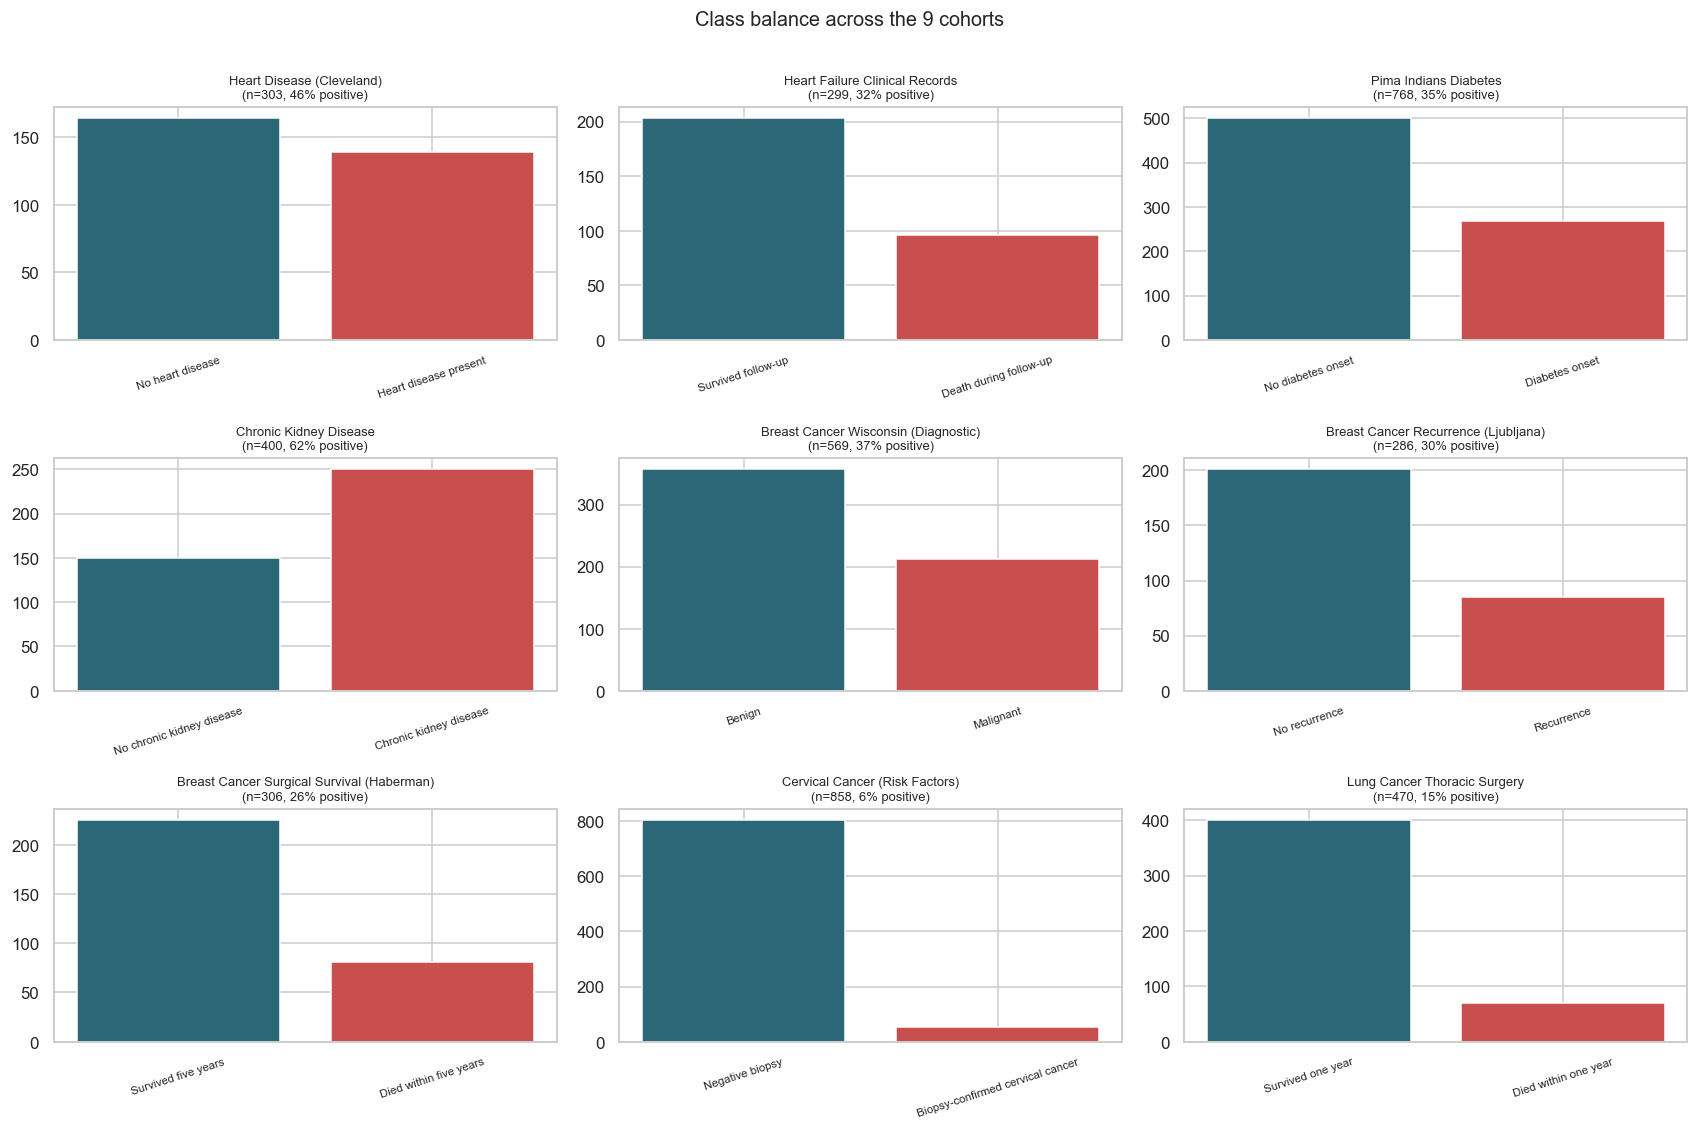

,dataset,n,negative,positive,positive_rate,majority_baseline
0,Heart Disease (Cleveland),303,164,139,0.459,0.541
1,Heart Failure Clinical Records,299,203,96,0.321,0.679
2,Pima Indians Diabetes,768,500,268,0.349,0.651
3,Chronic Kidney Disease,400,150,250,0.625,0.625
4,Breast Cancer Wisconsin (Diagnostic),569,357,212,0.373,0.627
5,Breast Cancer Recurrence (Ljubljana),286,201,85,0.297,0.703
6,Breast Cancer Surgical Survival (Haberman),306,225,81,0.265,0.735
7,Cervical Cancer (Risk Factors),858,803,55,0.064,0.936
8,Lung Cancer Thoracic Surgery,470,400,70,0.149,0.851


All 9 cohorts present in the class-balance table.


In [3]:
# A wrapping grid, and one axis per dataset. The earlier version of this cell used
# `plt.subplots(1, 4)` and `zip(axes, DATASETS.items())`, which was correct for
# four datasets and silently wrong for nine: `zip` stops at the shorter argument,
# so adding the oncology cohorts dropped five of them from both the figure and the
# table below with no error and no warning. The assertion at the end is what turns
# a recurrence of that mistake into a failure instead of a quiet omission.
n_datasets = len(schema.DATASETS)
cols = 3
rows = int(np.ceil(n_datasets / cols))
fig, axes = plt.subplots(rows, cols, figsize=(5.2 * cols, 3.4 * rows))
axes = np.atleast_1d(axes).ravel()
balance_rows = []

for ax, (slug, ds) in zip(axes, schema.DATASETS.items()):
    X, y = data.load_raw(slug)
    counts = y.value_counts().sort_index()
    pos_rate = y.mean()
    balance_rows.append(
        {
            "dataset": ds.title,
            "n": len(y),
            "negative": int(counts.get(0, 0)),
            "positive": int(counts.get(1, 0)),
            "positive_rate": round(float(pos_rate), 3),
            "majority_baseline": round(float(max(1 - pos_rate, pos_rate)), 3),
        }
    )
    ax.bar(
        [ds.negative_label, ds.positive_label],
        [counts.get(0, 0), counts.get(1, 0)],
        color=["#2b6777", "#c94f4f"],
    )
    ax.set_title(f"{ds.title}\n(n={len(y)}, {pos_rate:.0%} positive)", fontsize=8.5)
    ax.tick_params(axis="x", labelsize=7.5, rotation=18)

for ax in axes[n_datasets:]:
    ax.axis("off")

plt.suptitle(f"Class balance across the {n_datasets} cohorts", y=1.005, fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES / "01_class_balance.png")
plt.show()

balance = pd.DataFrame(balance_rows)
display(balance)

assert len(balance) == n_datasets, (
    f"class balance covers {len(balance)} of {n_datasets} datasets — a plotting "
    "grid smaller than the registry has silently truncated the table"
)
print(f"All {n_datasets} cohorts present in the class-balance table.")

`majority_baseline` is the accuracy of a model that always predicts the
majority class. Any model in notebook 03 that fails to beat this number is
worthless regardless of how good its accuracy looks in isolation.

## 1.3 Missingness

Missingness is where the nine datasets differ most, and it drives two separate
decisions: how to impute, and whether the missingness itself carries signal.

,dataset,feature,missing_fraction,missing_rows
0,Heart Disease (Cleveland),Major vessels coloured by fluoroscopy,0.0132,4
1,Heart Disease (Cleveland),Thallium perfusion scan,0.0066,2
2,Pima Indians Diabetes,2-hour serum insulin,0.4870,374
3,Pima Indians Diabetes,Triceps skin fold thickness,0.2956,227
4,Pima Indians Diabetes,Diastolic blood pressure,0.0508,39
5,Pima Indians Diabetes,Body mass index,0.0143,11
6,Pima Indians Diabetes,Plasma glucose (2-hour OGTT),0.0065,5
7,Chronic Kidney Disease,Red blood cells (urine microscopy),0.3800,152
8,Chronic Kidney Disease,Red blood cell count,0.3275,131
9,Chronic Kidney Disease,White blood cell count,0.2650,106


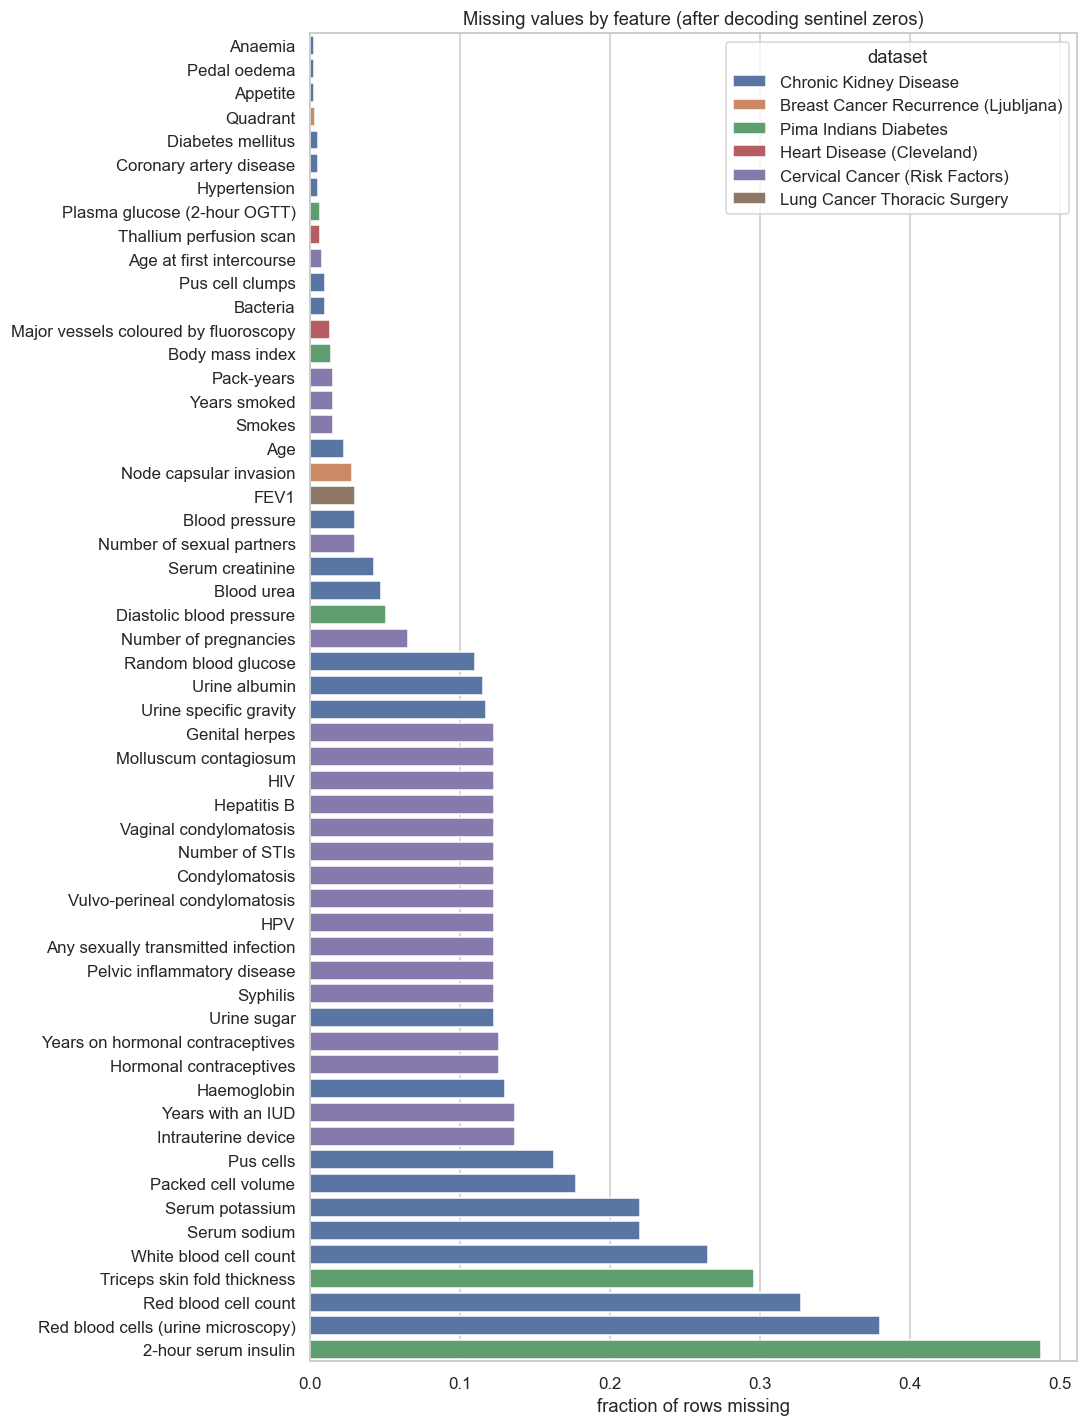

In [4]:
miss_rows = []
for slug, ds in schema.DATASETS.items():
    X, _ = data.load_raw(slug)  # zero-as-missing already converted to NaN
    frac = X.isna().mean()
    for feat, value in frac[frac > 0].sort_values(ascending=False).items():
        miss_rows.append(
            {
                "dataset": ds.title,
                "feature": ds.feature(feat).label,
                "missing_fraction": round(float(value), 4),
                "missing_rows": int(X[feat].isna().sum()),
            }
        )

missing = pd.DataFrame(miss_rows)
display(missing)

fig, ax = plt.subplots(figsize=(9, max(4, 0.28 * len(missing))))
sns.barplot(
    data=missing.sort_values("missing_fraction"),
    y="feature", x="missing_fraction", hue="dataset", dodge=False, ax=ax,
)
ax.set_title("Missing values by feature (after decoding sentinel zeros)")
ax.set_xlabel("fraction of rows missing")
ax.set_ylabel("")
plt.savefig(FIGURES / "01_missingness.png")
plt.show()

Three findings that change the pipeline:

1. **Pima diabetes has hidden missingness.** The raw file has zero NaNs, yet
   `Insulin` is 0 in 374 of 768 rows and `SkinThickness` in 227. A serum
   insulin of 0 mu U/mL is not a patient, it is an unrecorded measurement. Any
   pipeline that reads the CSV at face value trains on impossible physiology,
   and then explains its predictions in terms of it. We convert these sentinel
   zeros to NaN in `xai.data.load_raw` before imputing.
2. **CKD missingness is severe and not random.** Red-cell morphology is absent
   in 38% of records, and it is missing *because the clinician did not order
   the test* — which itself correlates with how sick the patient looked. Median
   imputation would fill 152 rows with one identical value and manufacture a
   fake modal patient, so this dataset gets KNN imputation.
3. **Cleveland heart disease is almost complete** (6 missing values total), so
   median imputation is adequate and anything fancier is unjustified cost.

## 1.4 Correlation structure

Read for two things: features that plausibly relate to the outcome, and
feature pairs so collinear that attribution will be split arbitrarily between
them. The second matters directly for explainability — SHAP splits credit
between correlated features, so two redundant columns each look half as
important as the concept they jointly measure.

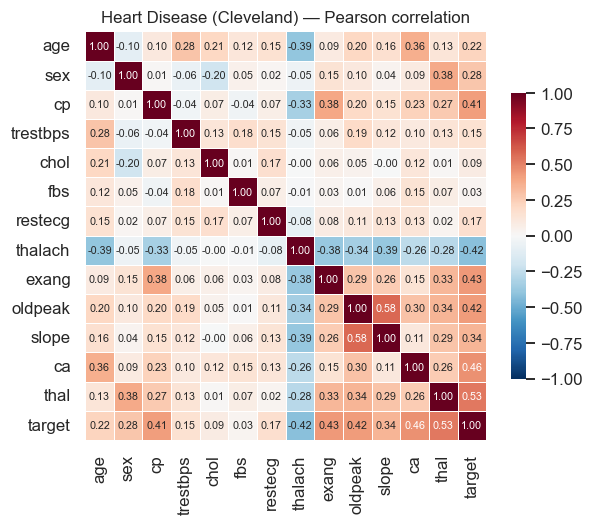

Heart Disease (Cleveland): strongest linear correlates of the outcome
   Thallium perfusion scan                    r = +0.526
   Major vessels coloured by fluoroscopy      r = +0.460
   Exercise-induced angina                    r = +0.432
   ST depression (exercise vs rest)           r = +0.425
   Maximum heart rate achieved                r = -0.417



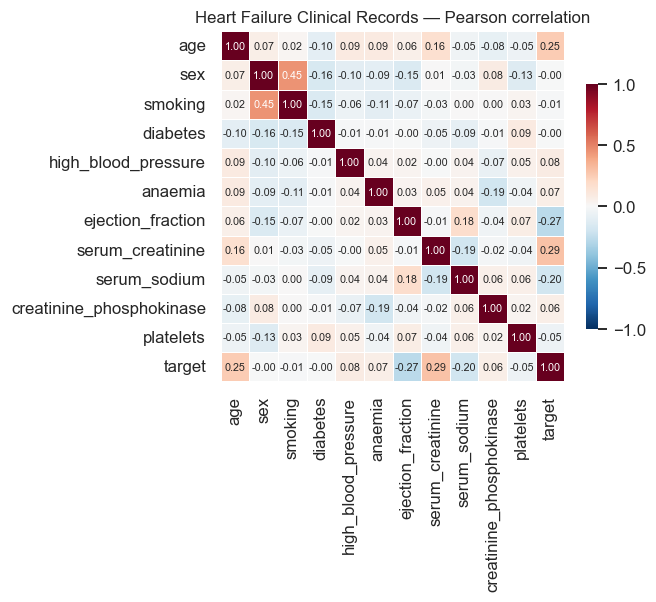

Heart Failure Clinical Records: strongest linear correlates of the outcome
   Serum creatinine                           r = +0.294
   Ejection fraction                          r = -0.269
   Age                                        r = +0.254
   Serum sodium                               r = -0.195
   Hypertension                               r = +0.079



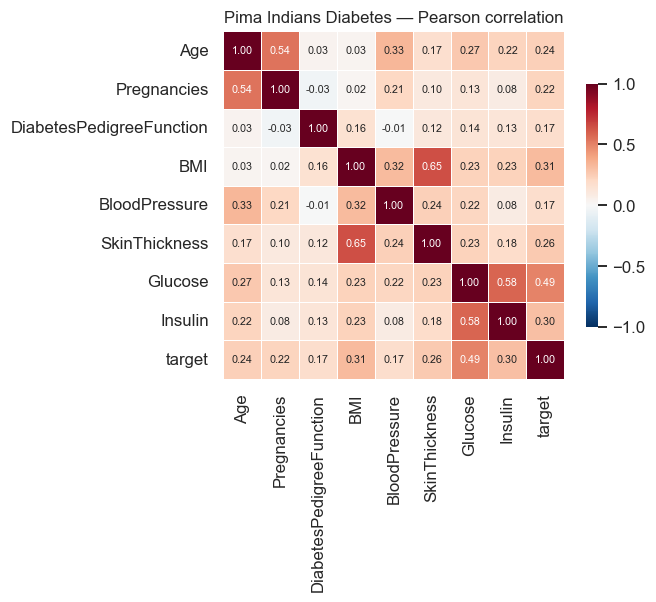

Pima Indians Diabetes: strongest linear correlates of the outcome
   Plasma glucose (2-hour OGTT)               r = +0.495
   Body mass index                            r = +0.314
   2-hour serum insulin                       r = +0.303
   Triceps skin fold thickness                r = +0.259
   Age                                        r = +0.238



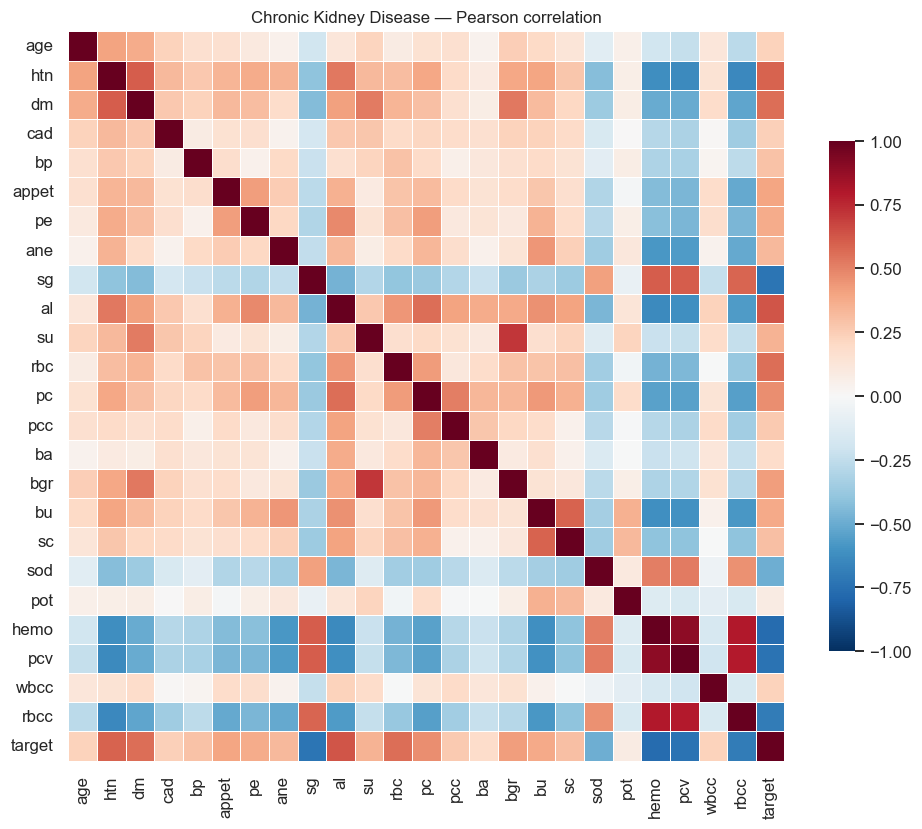

Chronic Kidney Disease: strongest linear correlates of the outcome
   Haemoglobin                                r = -0.769
   Packed cell volume                         r = -0.741
   Urine specific gravity                     r = -0.732
   Red blood cell count                       r = -0.699
   Urine albumin                              r = +0.627
   collinear pairs |r| > 0.7 (attribution will be split between them):
     Haemoglobin <-> Packed cell volume: +0.90
     Haemoglobin <-> Red blood cell count: +0.80
     Packed cell volume <-> Red blood cell count: +0.79
     Urine sugar <-> Random blood glucose: +0.72



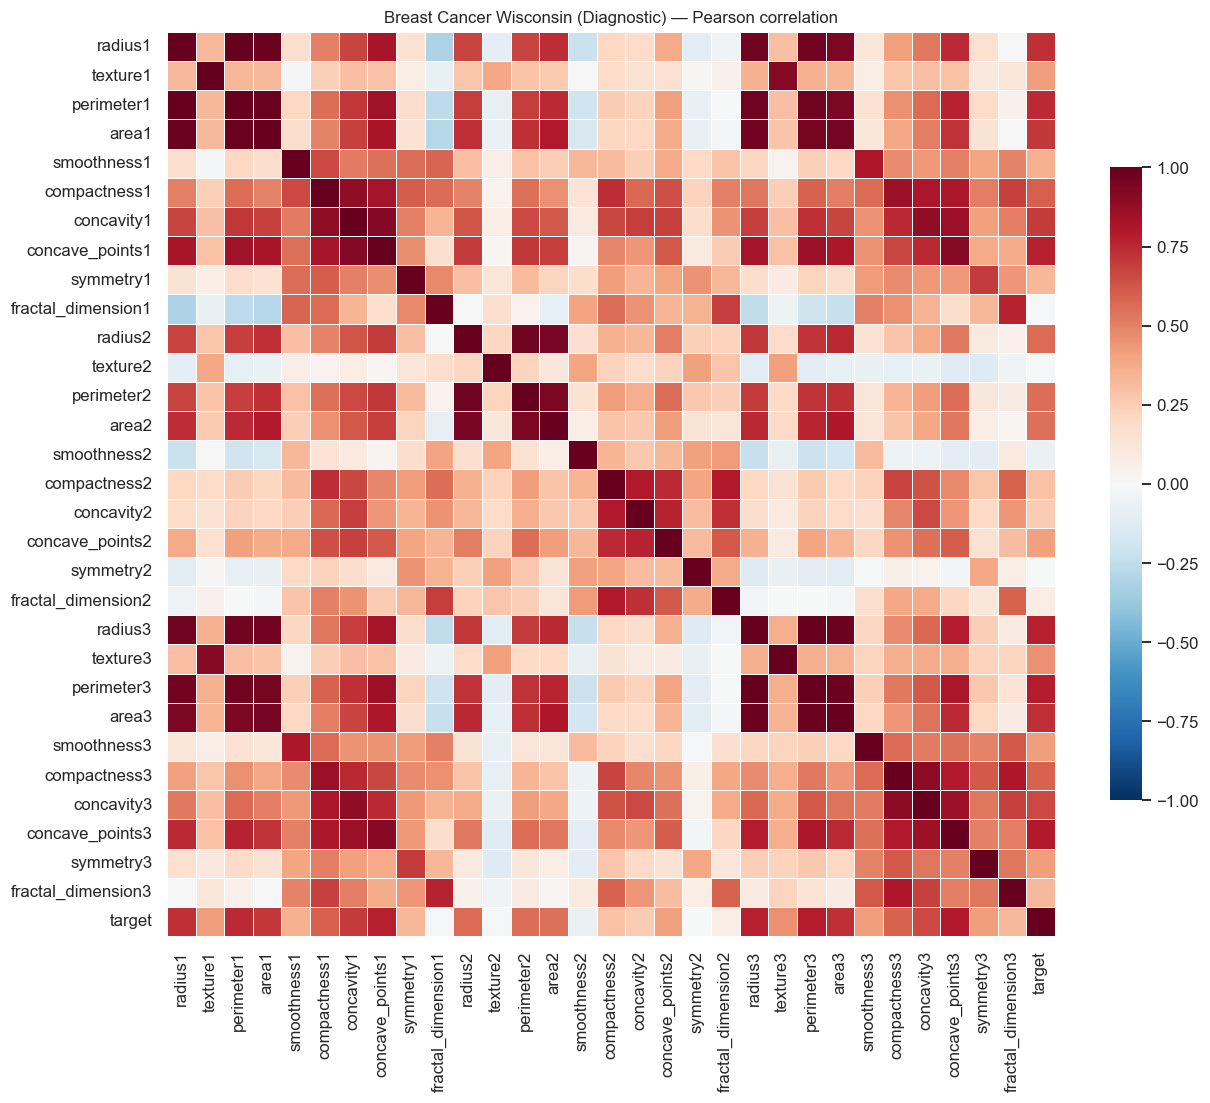

Breast Cancer Wisconsin (Diagnostic): strongest linear correlates of the outcome
   Concave points (worst)                     r = +0.794
   Perimeter (worst)                          r = +0.783
   Concave points (mean)                      r = +0.777
   Radius (worst)                             r = +0.776
   Perimeter (mean)                           r = +0.743
   collinear pairs |r| > 0.7 (attribution will be split between them):
     Radius (mean) <-> Perimeter (mean): +1.00
     Radius (worst) <-> Perimeter (worst): +0.99
     Radius (mean) <-> Area (mean): +0.99
     Perimeter (mean) <-> Area (mean): +0.99
     Radius (worst) <-> Area (worst): +0.98
     Perimeter (worst) <-> Area (worst): +0.98
     Radius (variability) <-> Perimeter (variability): +0.97
     Perimeter (mean) <-> Perimeter (worst): +0.97
     Radius (mean) <-> Radius (worst): +0.97
     Perimeter (mean) <-> Radius (worst): +0.97
     Radius (mean) <-> Perimeter (worst): +0.97
     Area (mean) <-> Radius (worst):

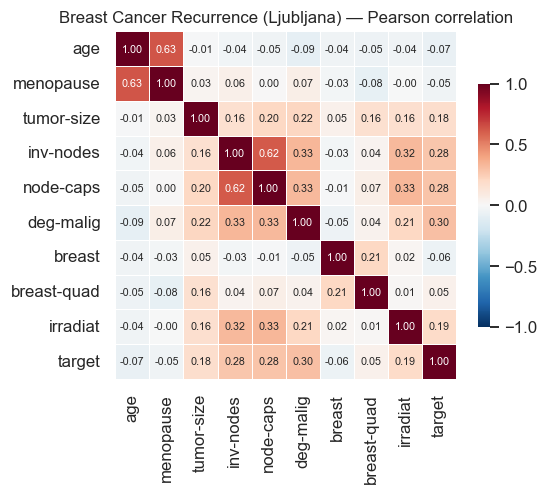

Breast Cancer Recurrence (Ljubljana): strongest linear correlates of the outcome
   Histological grade                         r = +0.299
   Node capsular invasion                     r = +0.285
   Involved axillary nodes (band midpoint)    r = +0.276
   Received radiotherapy                      r = +0.194
   Tumour size (band midpoint)                r = +0.175



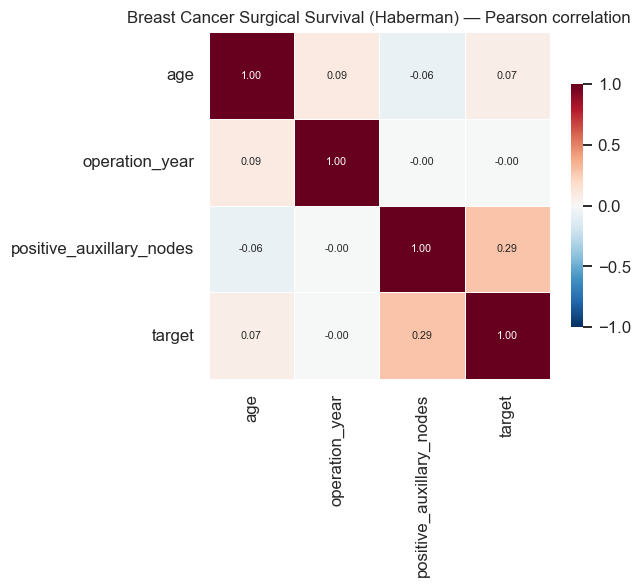

Breast Cancer Surgical Survival (Haberman): strongest linear correlates of the outcome
   Positive axillary nodes                    r = +0.287
   Age at operation                           r = +0.068
   Year of operation                          r = -0.005



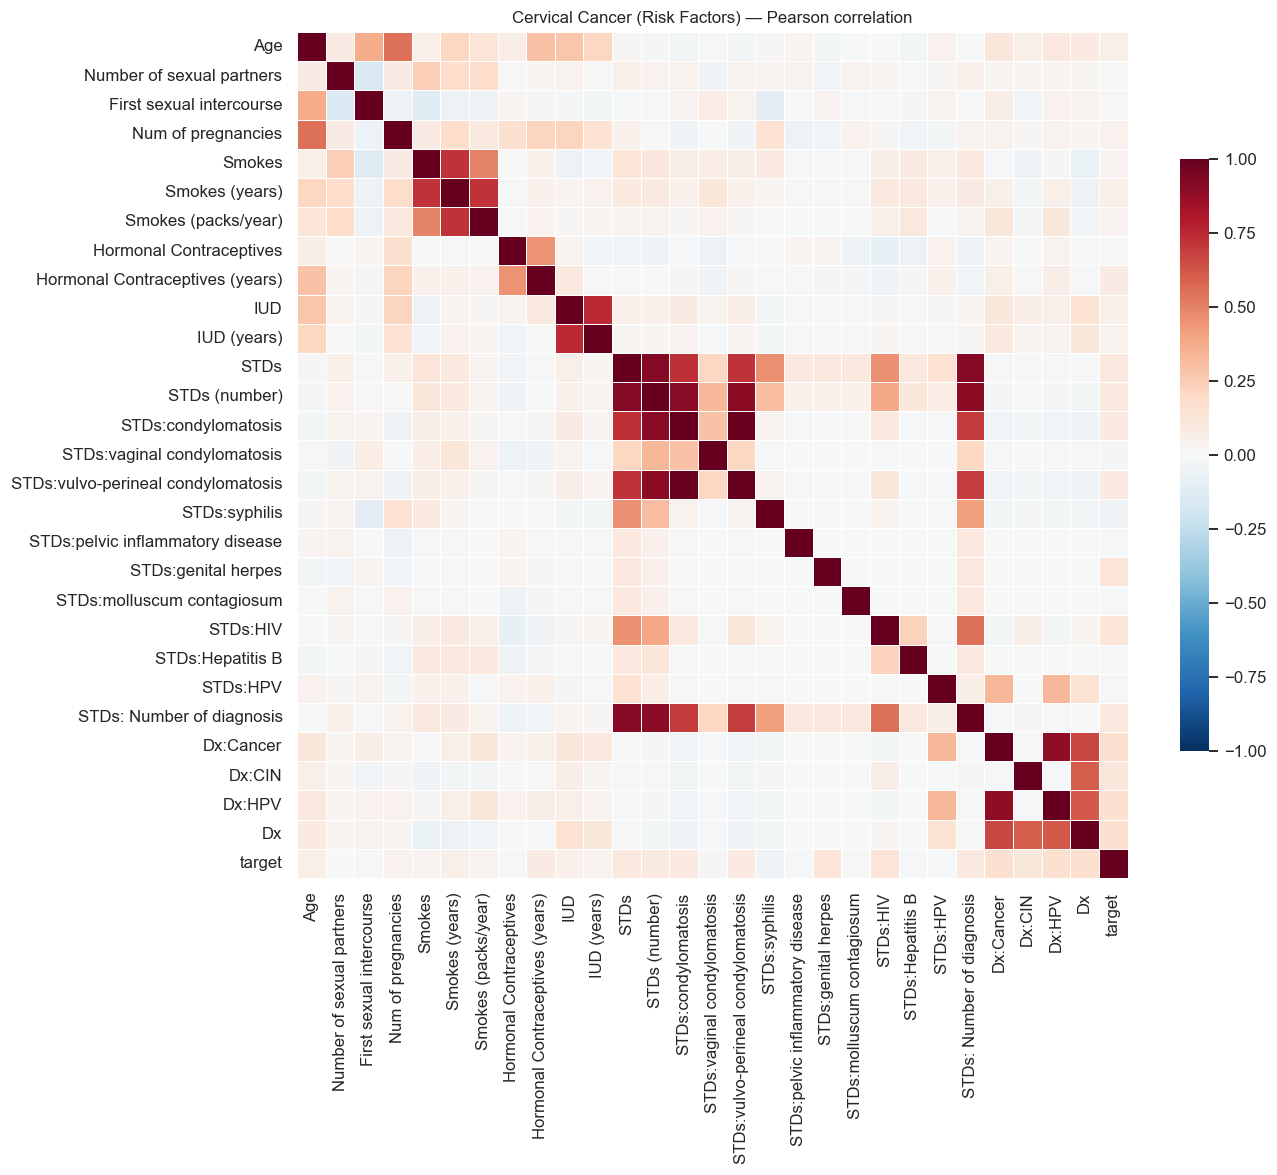

Cervical Cancer (Risk Factors): strongest linear correlates of the outcome
   Previous cancer diagnosis                  r = +0.161
   Previous HPV diagnosis                     r = +0.161
   Any previous diagnosis                     r = +0.158
   Genital herpes                             r = +0.133
   HIV                                        r = +0.127
   collinear pairs |r| > 0.7 (attribution will be split between them):
     Condylomatosis <-> Vulvo-perineal condylomatosis: +0.99
     Any sexually transmitted infection <-> Number of STIs: +0.92
     Any sexually transmitted infection <-> Number of STI diagnoses: +0.91
     Number of STIs <-> Condylomatosis: +0.90
     Number of STIs <-> Number of STI diagnoses: +0.90
     Number of STIs <-> Vulvo-perineal condylomatosis: +0.89
     Previous cancer diagnosis <-> Previous HPV diagnosis: +0.89
     Intrauterine device <-> Years with an IUD: +0.75
     Any sexually transmitted infection <-> Condylomatosis: +0.73
     Years smoked <-

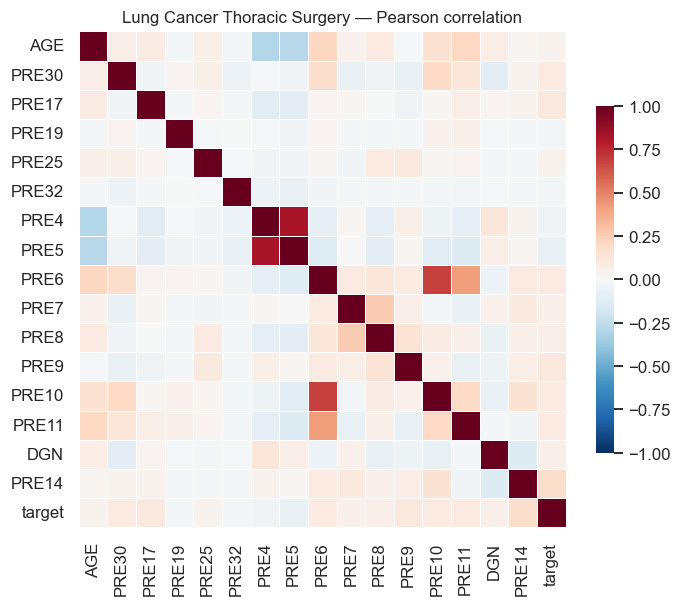

Lung Cancer Thoracic Surgery: strongest linear correlates of the outcome
   Tumour size (clinical T stage)             r = +0.174
   Type 2 diabetes                            r = +0.109
   Dyspnoea before surgery                    r = +0.106
   Performance status (Zubrod)                r = +0.093
   Cough before surgery                       r = +0.089
   collinear pairs |r| > 0.7 (attribution will be split between them):
     Forced vital capacity (FVC) <-> FEV1: +0.82



In [5]:
for slug, ds in schema.DATASETS.items():
    X, y = data.load_raw(slug)
    frame = X.copy()
    frame["target"] = y
    corr = frame.corr(numeric_only=True)

    size = max(5.0, 0.42 * len(frame.columns))
    fig, ax = plt.subplots(figsize=(size, size * 0.82))
    sns.heatmap(
        corr, cmap="RdBu_r", center=0, vmin=-1, vmax=1, square=False,
        linewidths=0.4, cbar_kws={"shrink": 0.7},
        annot=len(frame.columns) <= 14, fmt=".2f", annot_kws={"size": 7}, ax=ax,
    )
    ax.set_title(f"{ds.title} — Pearson correlation", fontsize=11)
    plt.savefig(FIGURES / f"01_corr_{slug}.png")
    plt.show()

    tgt = corr["target"].drop("target").sort_values(key=abs, ascending=False)
    print(f"{ds.title}: strongest linear correlates of the outcome")
    for feat, r in tgt.head(5).items():
        print(f"   {ds.feature(feat).label:<42} r = {r:+.3f}")

    upper = corr.drop(columns="target").drop(index="target")
    pairs = (
        upper.where(np.triu(np.ones(upper.shape), k=1).astype(bool))
        .stack()
        .sort_values(key=abs, ascending=False)
    )
    strong = pairs[abs(pairs) > 0.7]
    if len(strong):
        print("   collinear pairs |r| > 0.7 (attribution will be split between them):")
        for (a, b), r in strong.items():
            print(f"     {ds.feature(a).label} <-> {ds.feature(b).label}: {r:+.2f}")
    print()

## 1.5 Per-feature distributions by outcome

Class-conditional distributions preview which features a model can separate on
— and give us a prior to check the SHAP rankings against in notebook 04. If
SHAP later ranks a feature whose two distributions sit on top of each other as
the top driver, that is a red flag about the model, not an insight.

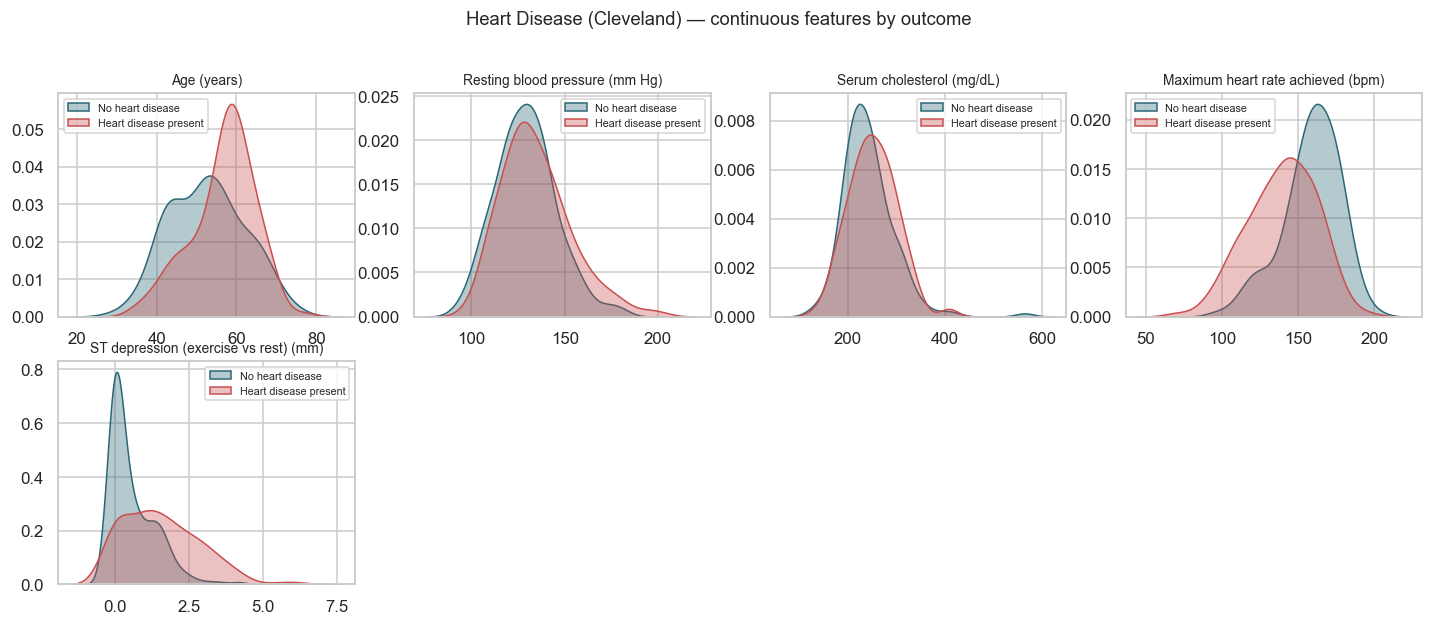

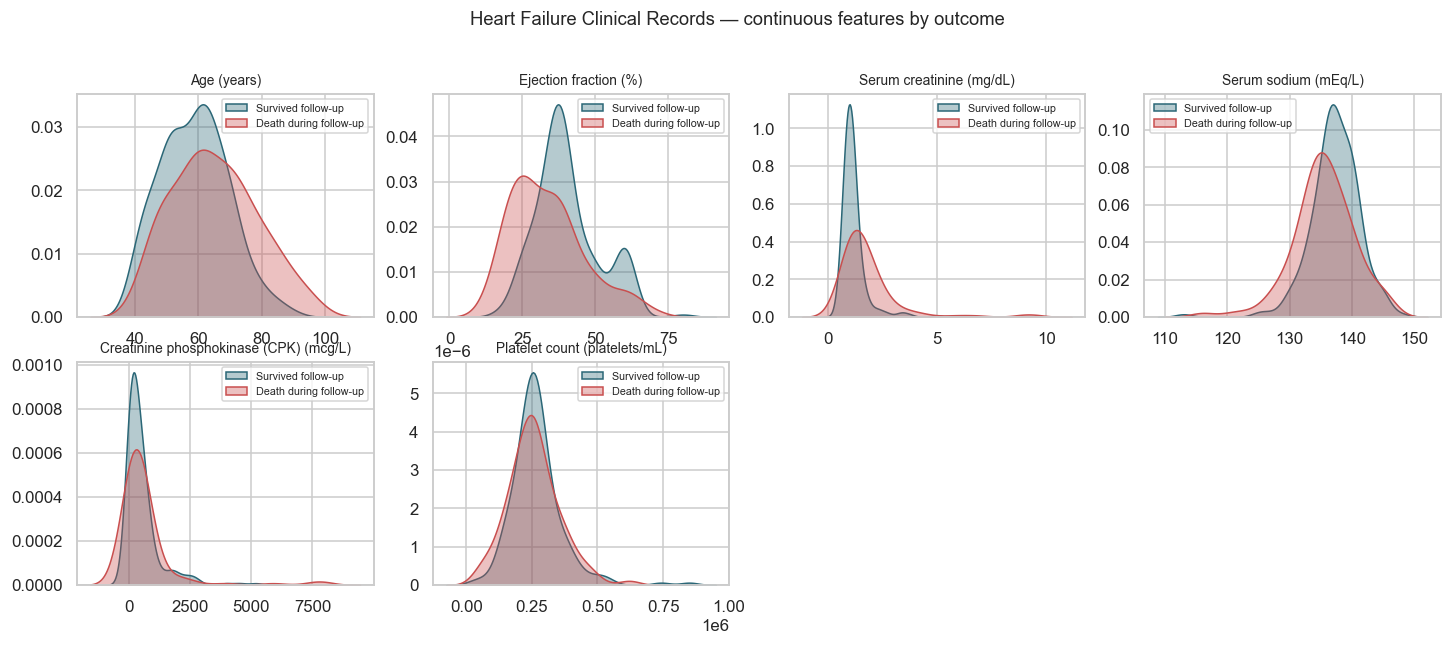

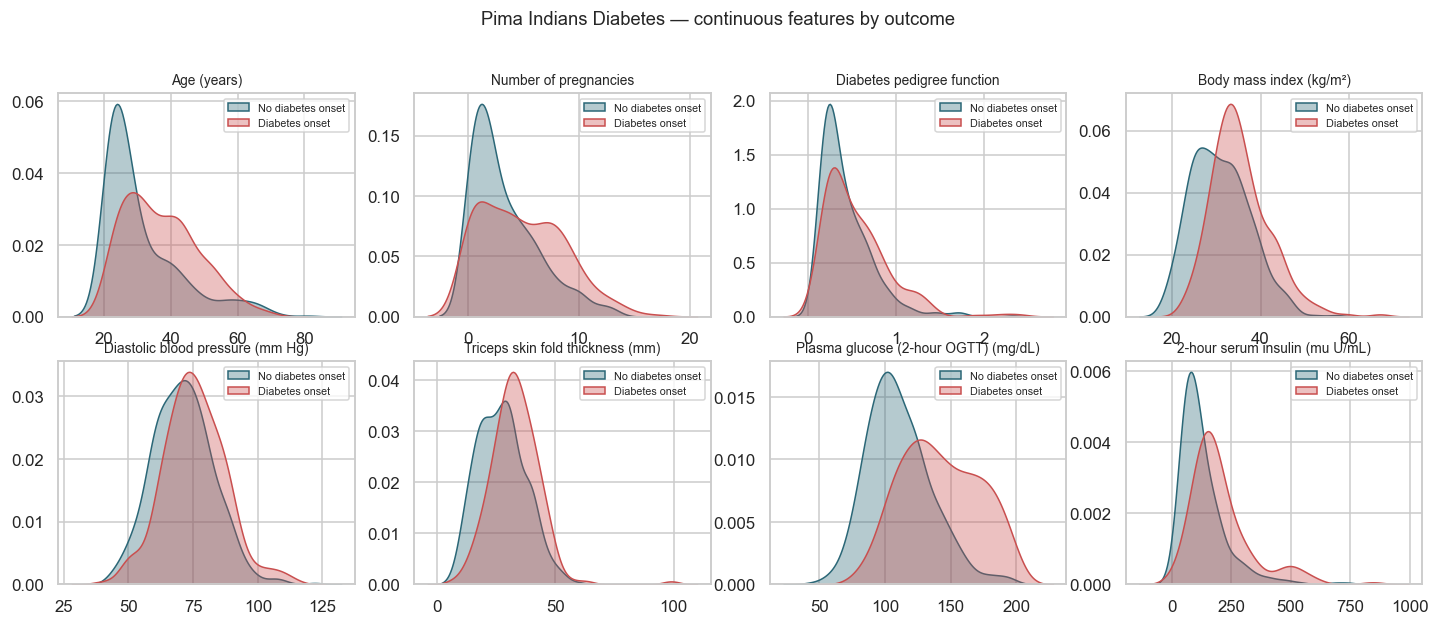

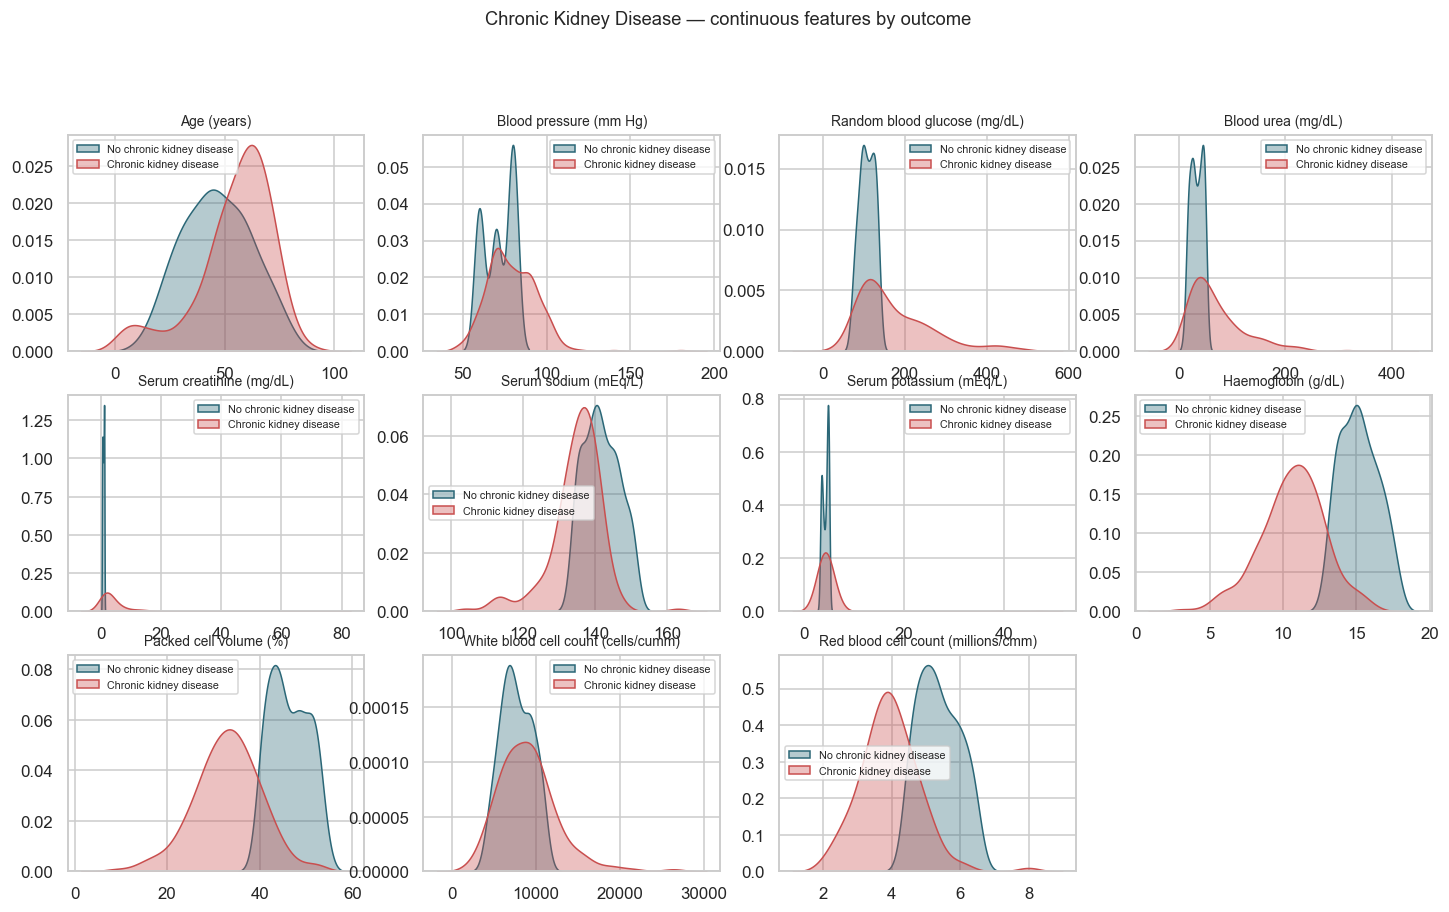

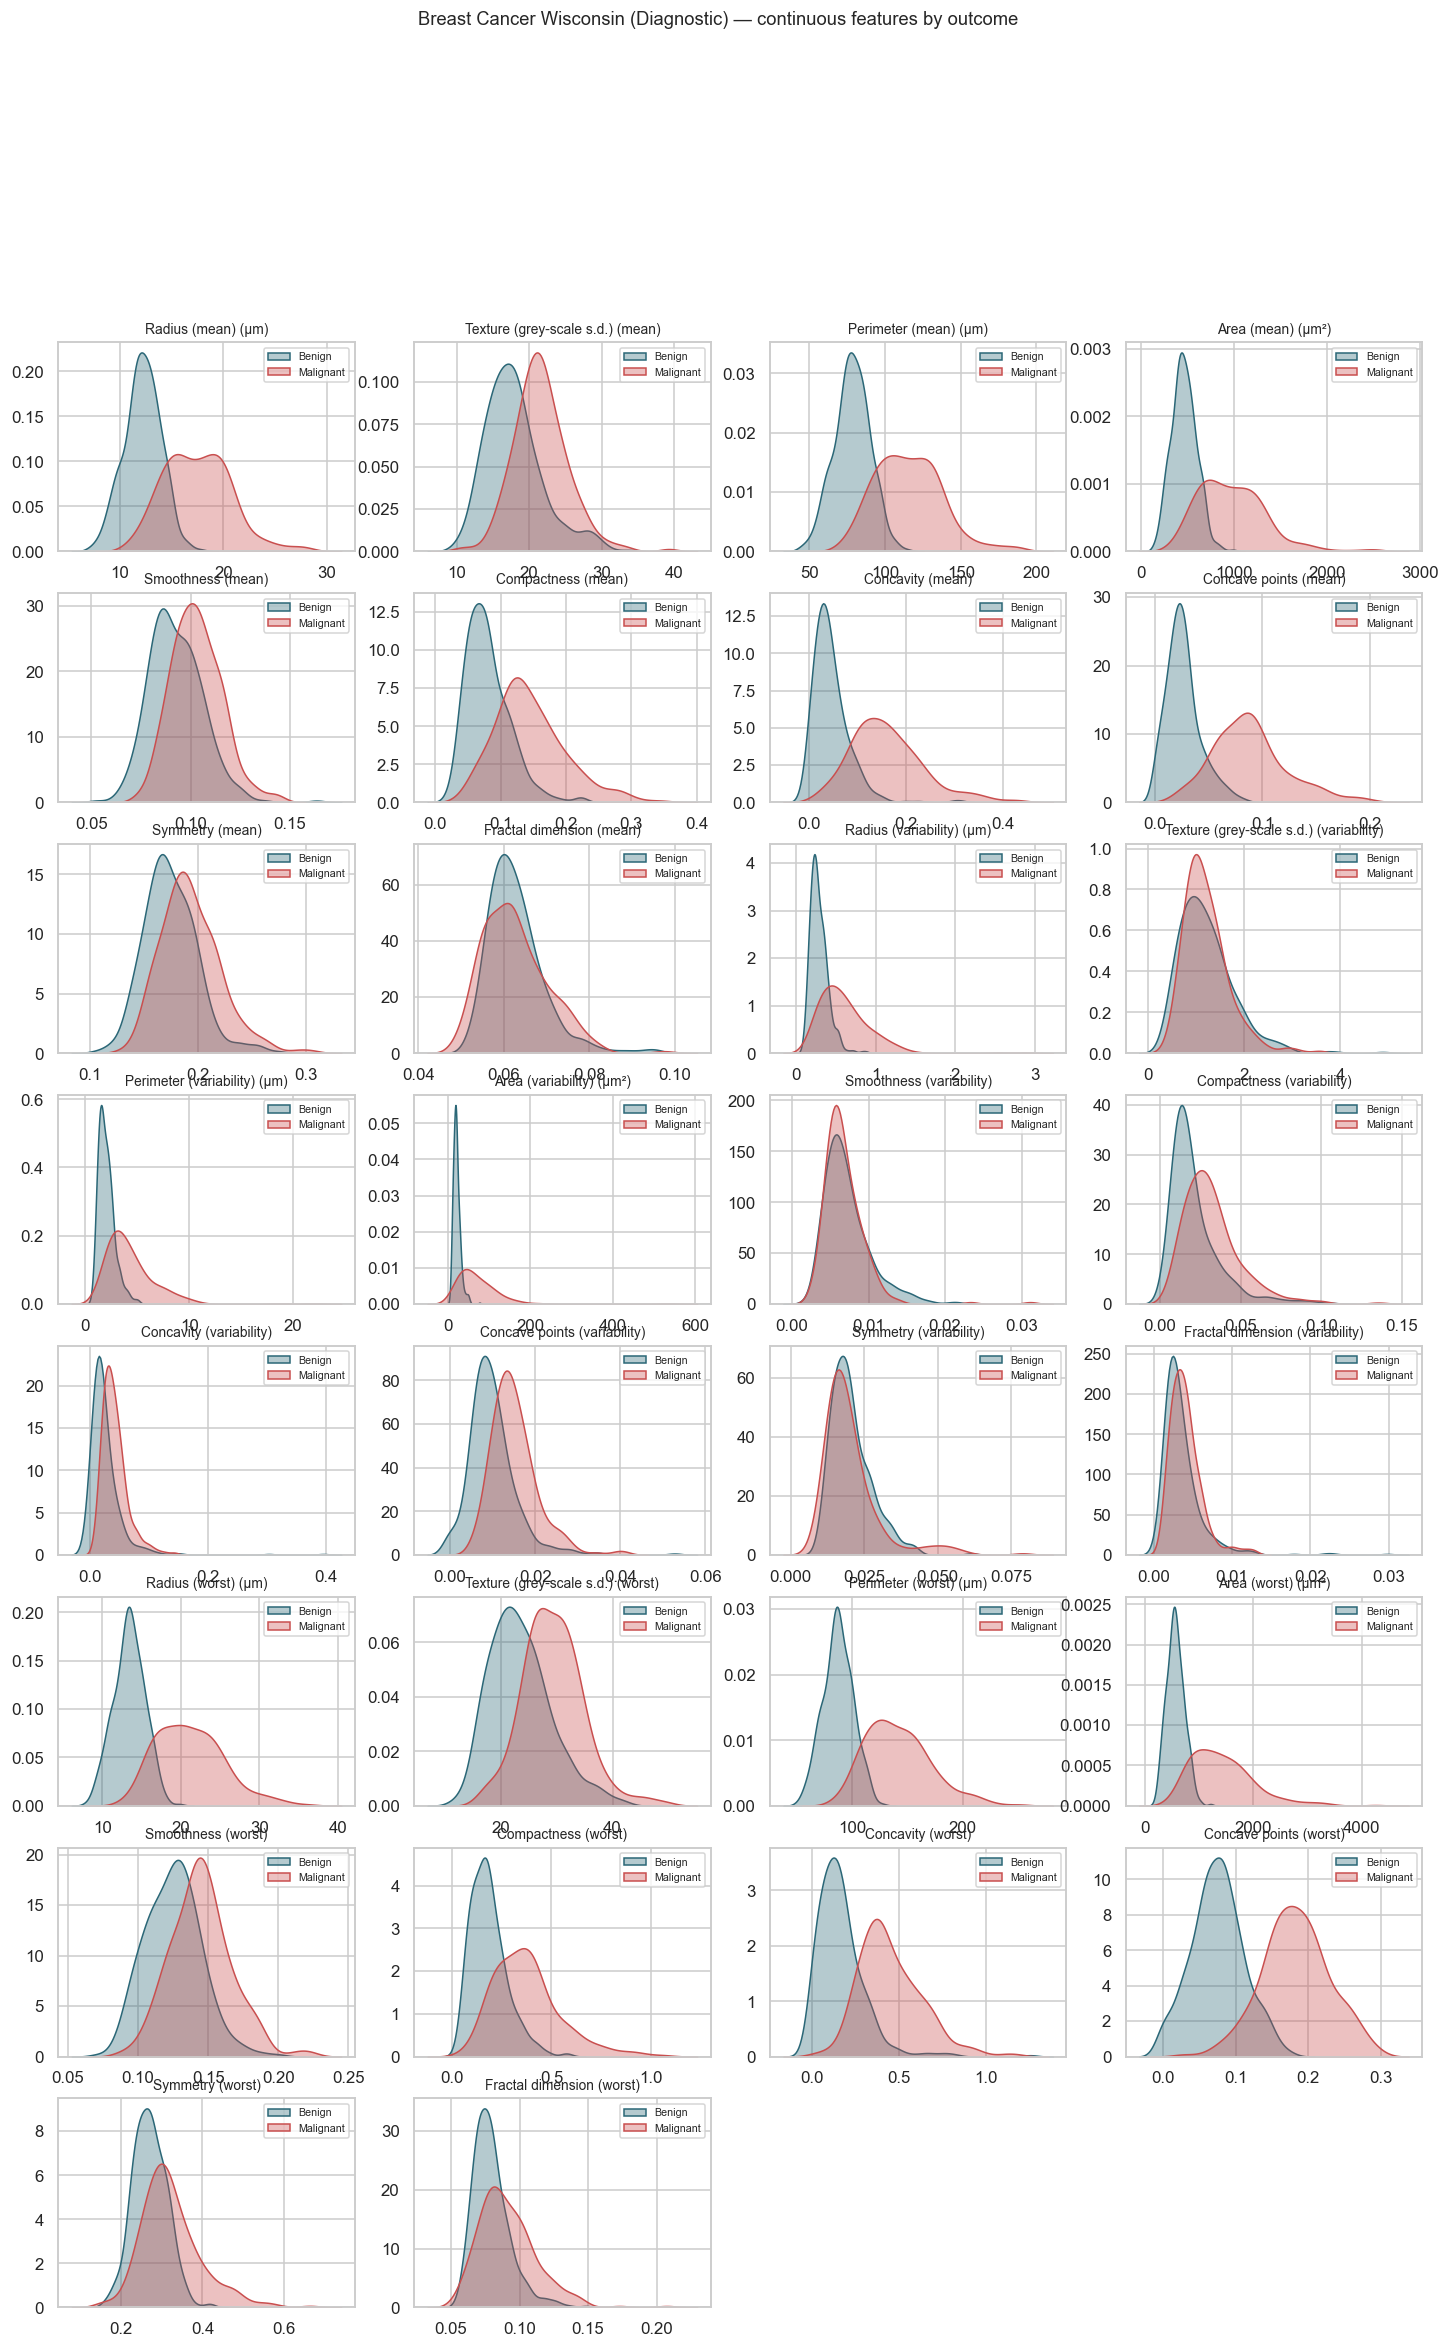

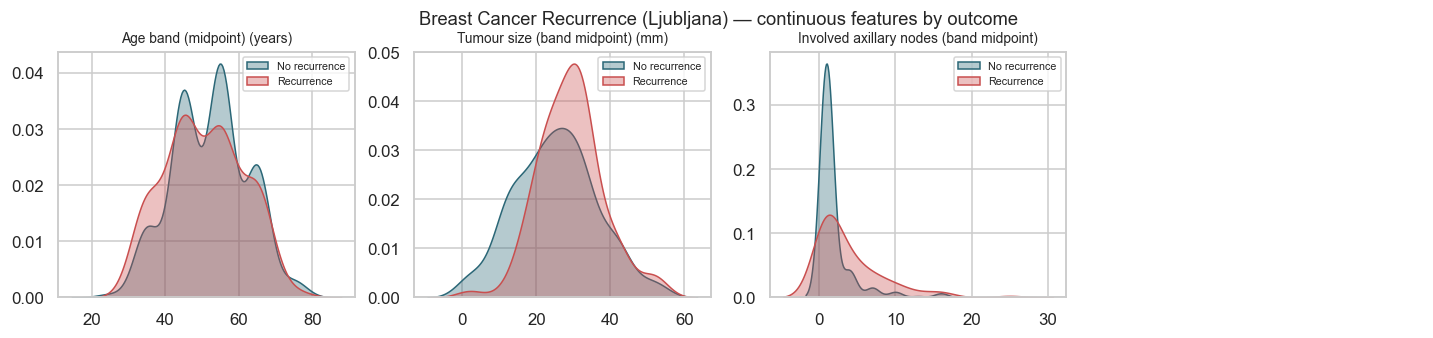

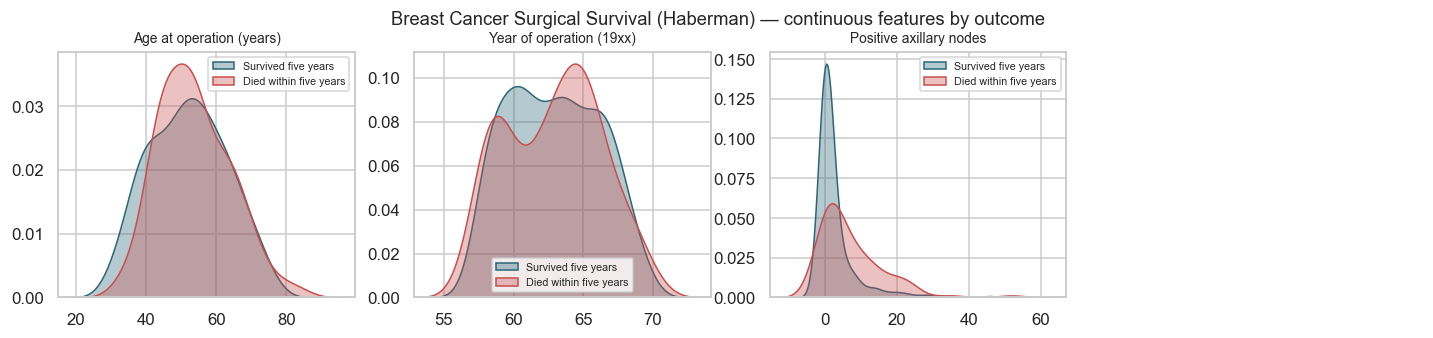

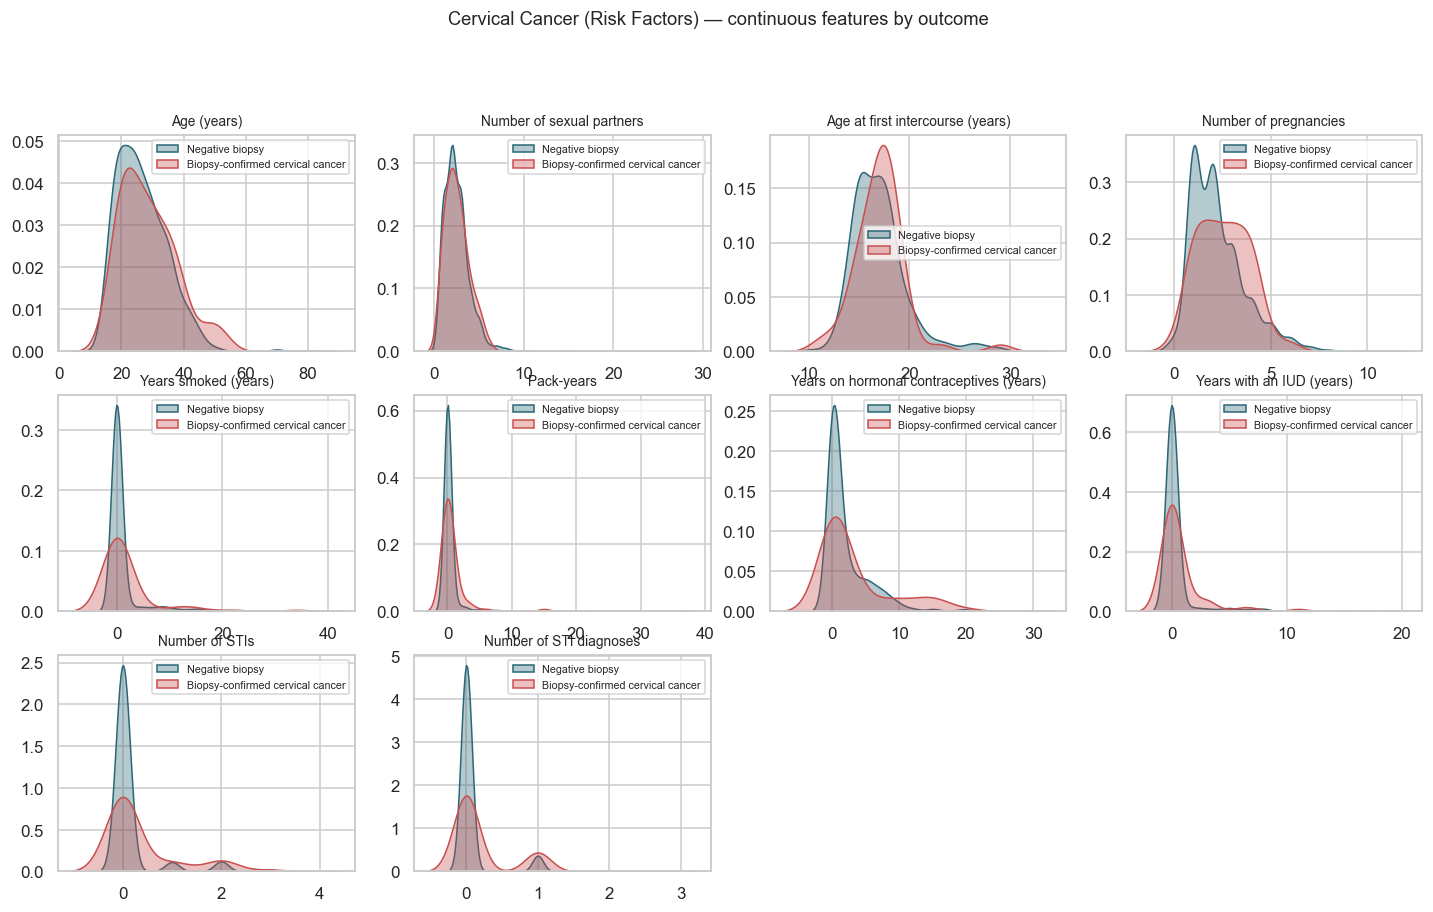

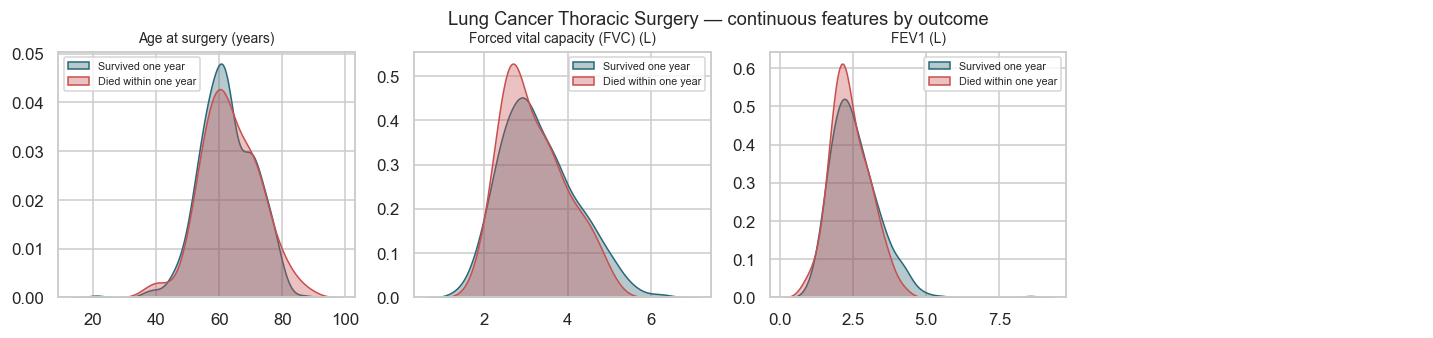

In [6]:
for slug, ds in schema.DATASETS.items():
    X, y = data.load_raw(slug)
    continuous = [f for f in ds.features if f.kind == "numeric"]
    if not continuous:
        continue
    cols = 4
    rows = int(np.ceil(len(continuous) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 2.9 * rows))
    axes = np.atleast_1d(axes).ravel()

    for ax, feat in zip(axes, continuous):
        for cls, colour, label in (
            (0, "#2b6777", ds.negative_label),
            (1, "#c94f4f", ds.positive_label),
        ):
            values = X.loc[y == cls, feat.name].dropna()
            if len(values) > 1:
                sns.kdeplot(values, ax=ax, fill=True, alpha=0.35,
                            color=colour, label=label, warn_singular=False)
        ax.set_title(f"{feat.label}" + (f" ({feat.unit})" if feat.unit else ""),
                     fontsize=9)
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.legend(fontsize=7)
    for ax in axes[len(continuous):]:
        ax.axis("off")

    plt.suptitle(f"{ds.title} — continuous features by outcome", y=1.01, fontsize=12)
    plt.savefig(FIGURES / f"01_dist_{slug}.png")
    plt.show()

## 1.6 Binary and ordinal features

In [7]:
for slug, ds in schema.DATASETS.items():
    X, y = data.load_raw(slug)
    discrete = [f for f in ds.features if f.kind in ("binary", "ordinal")]
    if not discrete:
        continue
    print(f"\n=== {ds.title}: positive-outcome rate by category ===")
    for feat in discrete:
        grouped = y.groupby(X[feat.name].round(3)).agg(["mean", "size"])
        rendered = {
            schema.display_value(ds, feat.name, k): f"{v['mean']:.0%} (n={int(v['size'])})"
            for k, v in grouped.iterrows()
        }
        print(f"  {feat.label:<44} {rendered}")


=== Heart Disease (Cleveland): positive-outcome rate by category ===
  Sex                                          {'Female': '26% (n=97)', 'Male': '55% (n=206)'}
  Chest pain type                              {'Typical angina': '30% (n=23)', 'Atypical angina': '18% (n=50)', 'Non-anginal pain': '21% (n=86)', 'Asymptomatic': '73% (n=144)'}
  Fasting blood sugar > 120 mg/dL              {'No': '45% (n=258)', 'Yes': '49% (n=45)'}
  Resting ECG                                  {'Normal': '37% (n=151)', 'ST-T wave abnormality': '75% (n=4)', 'Left ventricular hypertrophy': '54% (n=148)'}
  Exercise-induced angina                      {'No': '31% (n=204)', 'Yes': '77% (n=99)'}
  ST segment slope at peak exercise            {'Upsloping': '25% (n=142)', 'Flat': '65% (n=140)', 'Downsloping': '57% (n=21)'}
  Major vessels coloured by fluoroscopy        {'0': '26% (n=176)', '1': '68% (n=65)', '2': '82% (n=38)', '3': '85% (n=20)'}
  Thallium perfusion scan                      {'Normal': '22% (n=

## 1.7 A leakage feature we are going to remove

The heart-failure dataset ships a `time` column: days of follow-up. It is the
strongest single correlate of the death event, and it is worthless.

It describes when observation stopped, not the patient. Patients who died early
have, by construction, short follow-up. A model given `time` learns the study's
censoring pattern and reports ~0.90 AUC, and the explanation it produces is
"this patient was only observed for 30 days" — which cannot inform any clinical
decision because at admission the follow-up duration does not yet exist.

This is textbook shortcut learning, and it is the exact failure that the
literature survey cites as the reason black-box accuracy alone is not
trustworthy in healthcare. It is also invisible to accuracy metrics: the model
looks *better*. Only an explanation exposes it. We quantify it, then drop the
column for good in `xai.schema.HEART_FAILURE.drop_columns`.

In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split

raw_hf = pd.read_csv(ROOT / "data" / "raw" / "heart_failure.csv")
y_hf = raw_hf["target"].astype(int)

print(f"corr(time, death_event) = {raw_hf['time'].corr(y_hf):+.3f}\n")

for label, frame in (
    ("WITH `time` (leaky)", raw_hf.drop(columns=["target"])),
    ("WITHOUT `time` (honest)", raw_hf.drop(columns=["target", "time"])),
):
    Xtr, Xte, ytr, yte = train_test_split(
        frame, y_hf, test_size=0.2, random_state=42, stratify=y_hf
    )
    imp = SimpleImputer(strategy="median").fit(Xtr)
    rf = RandomForestClassifier(n_estimators=300, random_state=42).fit(
        imp.transform(Xtr), ytr
    )
    auc = roc_auc_score(yte, rf.predict_proba(imp.transform(Xte))[:, 1])
    top = (
        pd.Series(rf.feature_importances_, index=frame.columns)
        .sort_values(ascending=False)
        .head(3)
    )
    print(f"{label:<26} test AUC = {auc:.3f}")
    print(f"  top-3 importances: {', '.join(f'{k} {v:.2f}' for k, v in top.items())}\n")

corr(time, death_event) = -0.527



WITH `time` (leaky)        test AUC = 0.893
  top-3 importances: time 0.36, serum_creatinine 0.15, ejection_fraction 0.14



WITHOUT `time` (honest)    test AUC = 0.795
  top-3 importances: serum_creatinine 0.22, ejection_fraction 0.19, creatinine_phosphokinase 0.13



The leaky model wins on AUC and its top feature is the leak. Reported accuracy
would have hidden this completely; the feature ranking makes it obvious in one
line. That asymmetry is the thesis of this project in miniature.

## 1.8 Summary carried into notebook 02

| Dataset | n | Positive rate | Majority baseline | Missingness | Decision |
|---|---|---|---|---|---|
| Heart Disease (Cleveland) | 303 | 46% | 0.54 | 6 cells | median impute |
| Heart Failure | 299 | 32% | 0.68 | none | median impute, **drop `time`** |
| Pima Diabetes | 768 | 35% | 0.65 | sentinel zeros, Insulin 48.7% | zeros → NaN, median impute |
| Chronic Kidney Disease | 400 | 62% | 0.62 | up to 38%, non-random | **KNN impute (k=5)** |
| Breast Cancer (Wisconsin) | 569 | 37% | 0.63 | none | median impute; watch collinearity |
| Breast Cancer Recurrence | 286 | 30% | 0.70 | 10 cells | **repair Excel-mangled bands**, median impute |
| Breast Cancer Survival | 306 | 27% | 0.74 | none | median impute; only 3 features |
| Cervical Cancer | 858 | **6.4%** | **0.94** | 2 cols 91.7%, 2 constant | drop 4 cols, **KNN impute** |
| Lung Cancer Surgery | 470 | 15% | 0.85 | none raw | **FEV1 > 10 L → NaN**, median impute |

Two things to carry forward. All nine sets are small, so notebook 03 uses
cross-validated hyperparameter search rather than a separate validation split —
a single 60-row validation fold would give estimates too noisy to select on.

And the five oncology cohorts push the class balance much further than the
original four: cervical cancer is 6.4% positive, so a model predicting
"negative" for every patient scores 0.94 accuracy while finding no cancer at
all. Accuracy was already the wrong headline metric; on these datasets it is
actively misleading.

In [9]:
balance.to_json(ROOT / "results" / "01_class_balance.json", orient="records", indent=2)
missing.to_json(ROOT / "results" / "01_missingness.json", orient="records", indent=2)
print("wrote results/01_class_balance.json, results/01_missingness.json")
print(f"figures in {FIGURES.relative_to(ROOT)}:",
      len(list(FIGURES.glob('01_*.png'))), "files")

wrote results/01_class_balance.json, results/01_missingness.json
figures in results/figures: 20 files
